# Task 3: Transformer-Based Music Generator
**Course:** CSE425/EEE474 — Neural Networks  
**Dataset:** Groove MIDI → REMI Token Sequences  
**Model:** GPT-style Decoder-only Transformer  

---
### Mathematical Objective

**Autoregressive probability:**
$$p(X) = \prod_{t=1}^{T} p(x_t | x_{<t})$$

**Training loss (negative log-likelihood):**
$$\mathcal{L}_{TR} = -\sum_{t=1}^{T} \log p_\theta(x_t | x_{<t})$$

**Perplexity (evaluation metric):**
$$\text{Perplexity} = \exp\left(\frac{1}{T} \mathcal{L}_{TR}\right)$$

Lower perplexity = model assigns higher probability to real music sequences.

## 1. Setup & Imports

In [1]:
import os, sys, json, math
import numpy as np
import torch
import matplotlib.pyplot as plt
import pretty_midi
from pathlib import Path
from collections import Counter
from torch.utils.data import DataLoader

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
SRC  = os.path.join(ROOT, 'src')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

from miditok import REMI
from config import (
    DEVICE, MODEL_DIR, PLOT_DIR, MIDI_DIR,
    PROCESSED_DIR, RAW_DIR, BATCH_SIZE, EPOCHS,
    NHEAD, NUM_ENC_LAYERS, DIM_FEEDFORWARD,
    TF_DROPOUT, TF_MAX_LEN, LR
)
from models.transformer import MusicTransformer
from training.train_transformer import TokenDataset, compute_perplexity
from evaluation.metrics import (
    evaluate_midi_files, note_stats_from_midi,
    generate_random_baseline, generate_markov_baseline,
)
from evaluation.pitch_histogram import get_pitch_class_histogram
from evaluation.rhythm_score import rhythm_diversity_from_midi, repetition_ratio_from_midi

os.makedirs(PLOT_DIR, exist_ok=True)

print('=' * 55)
print(f'  Device  : {DEVICE}')
if torch.cuda.is_available():
    print(f'  GPU     : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM    : {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB')
print(f'  PyTorch : {torch.__version__}')
print('=' * 55)

d:\cse425_project\Unsupervised-Neural-Network-for-Multi-Genre-Music-Generation\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  Device  : cuda
  GPU     : NVIDIA GeForce RTX 3050 Laptop GPU
  VRAM    : 4.0 GB
  PyTorch : 2.5.1+cu121


## 2. Exploratory Data Analysis
Reusing raw MIDI analysis from Task 1, plus token-specific analysis.

Total MIDI files: 45555
Duration : mean=38.2s  max=48.0s
Notes    : mean=340  max=457


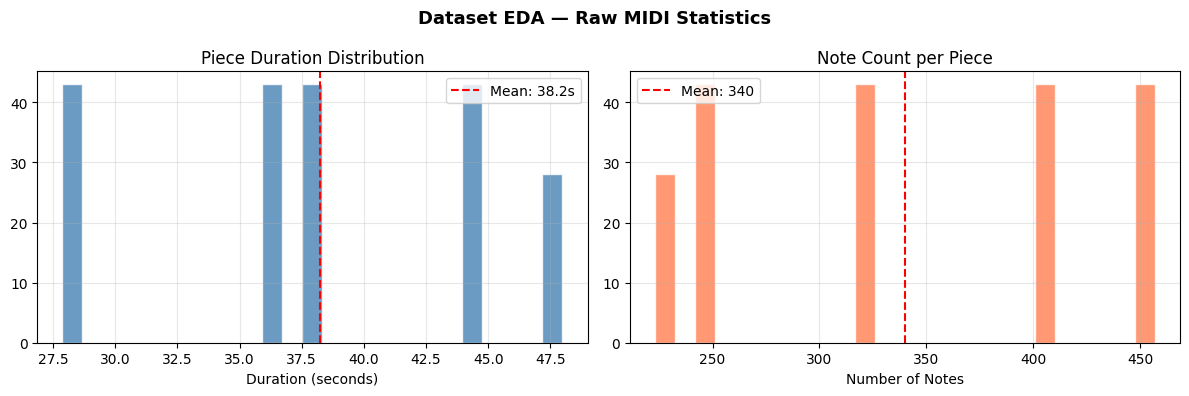

In [2]:
# Raw MIDI statistics
midi_files = []
for root, _, files in os.walk(RAW_DIR):
    for f in files:
        if f.lower().endswith(('.mid', '.midi')):
            midi_files.append(os.path.join(root, f))

print(f'Total MIDI files: {len(midi_files)}')

durations, note_counts = [], []
for path in midi_files[:200]:
    try:
        midi = pretty_midi.PrettyMIDI(path)
        durations.append(midi.get_end_time())
        note_counts.append(sum(len(i.notes) for i in midi.instruments))
    except:
        continue

print(f'Duration : mean={np.mean(durations):.1f}s  max={max(durations):.1f}s')
print(f'Notes    : mean={np.mean(note_counts):.0f}  max={max(note_counts)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Dataset EDA — Raw MIDI Statistics', fontsize=13, fontweight='bold')
axes[0].hist(durations, bins=25, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(np.mean(durations), color='red', linestyle='--', label=f'Mean: {np.mean(durations):.1f}s')
axes[0].set_title('Piece Duration Distribution')
axes[0].set_xlabel('Duration (seconds)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(note_counts, bins=25, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(np.mean(note_counts), color='red', linestyle='--', label=f'Mean: {np.mean(note_counts):.0f}')
axes[1].set_title('Note Count per Piece')
axes[1].set_xlabel('Number of Notes')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'task3_eda_midi.png'), dpi=150)
plt.show()

## 3. Token Preprocessing Analysis
REMI tokenization converts MIDI to integer sequences.

In [3]:
# Load tokenizer
tokenizer_path = os.path.join(PROCESSED_DIR, 'remi_tokenizer.json')
tokenizer      = REMI(params=Path(tokenizer_path))
vocab_size     = len(tokenizer.vocab)

print(f'Tokenizer    : REMI')
print(f'Vocab size   : {vocab_size}')
print(f'Max seq len  : {TF_MAX_LEN}')
print()

# Show some token examples
print('Sample vocabulary entries:')
for i, (k, v) in enumerate(list(tokenizer.vocab.items())[:20]):
    print(f'  {v:4d} → {k}')

Tokenizer    : REMI
Vocab size   : 348
Max seq len  : 512

Sample vocabulary entries:
     0 → PAD_None
     1 → BOS_None
     2 → EOS_None
     3 → MASK_None
     4 → Bar_None
     5 → Pitch_21
     6 → Pitch_22
     7 → Pitch_23
     8 → Pitch_24
     9 → Pitch_25
    10 → Pitch_26
    11 → Pitch_27
    12 → Pitch_28
    13 → Pitch_29
    14 → Pitch_30
    15 → Pitch_31
    16 → Pitch_32
    17 → Pitch_33
    18 → Pitch_34
    19 → Pitch_35


In [13]:
# Token frequency analysis
token_dir  = os.path.join(PROCESSED_DIR, 'tokens')
train_arr  = np.load(os.path.join(token_dir, 'train_tokens.npy'), mmap_mode='r')

print(f'Token dataset shape: {train_arr.shape}')
print(f'Total tokens       : {train_arr.size:,}')

# Sample token frequency from first 1000 sequences
sample = train_arr[:1000].flatten()
freq   = Counter(sample.tolist())
top20  = freq.most_common(20)

# Get token names using correct miditok 3.x API
def get_token_name(tokenizer, tid):
    try:
        # miditok 3.x way
        return str(tokenizer.vocab[tid])[:15]
    except:
        try:
            return str(list(tokenizer.vocab.keys())[tid])[:15]
        except:
            return f'ID_{tid}'

print('\nTop 20 most frequent tokens:')
for tid, count in top20:
    name = get_token_name(tokenizer, tid)
    print(f'  {tid:4d} ({name:<20}): {count:,}')

Token dataset shape: (144428, 512)
Total tokens       : 73,947,136

Top 20 most frequent tokens:
   127 (Duration_0.2.8      ): 60,673
   126 (Duration_0.1.8      ): 60,250
   233 (PitchDrum_38        ): 31,150
   231 (PitchDrum_36        ): 27,154
   284 (Rest_0.1.8          ): 24,228
   246 (PitchDrum_51        ): 16,000
   239 (PitchDrum_44        ): 15,913
   125 (Velocity_127        ): 10,136
   285 (Rest_0.2.8          ): 9,045
   237 (PitchDrum_42        ): 7,141
   235 (PitchDrum_40        ): 7,133
   105 (Velocity_47         ): 7,105
   103 (Velocity_39         ): 6,710
   286 (Rest_0.3.8          ): 6,367
   104 (Velocity_43         ): 6,182
   106 (Velocity_51         ): 6,181
   108 (Velocity_59         ): 5,829
   107 (Velocity_55         ): 5,758
   198 (Position_8          ): 5,707
   214 (Position_24         ): 5,628


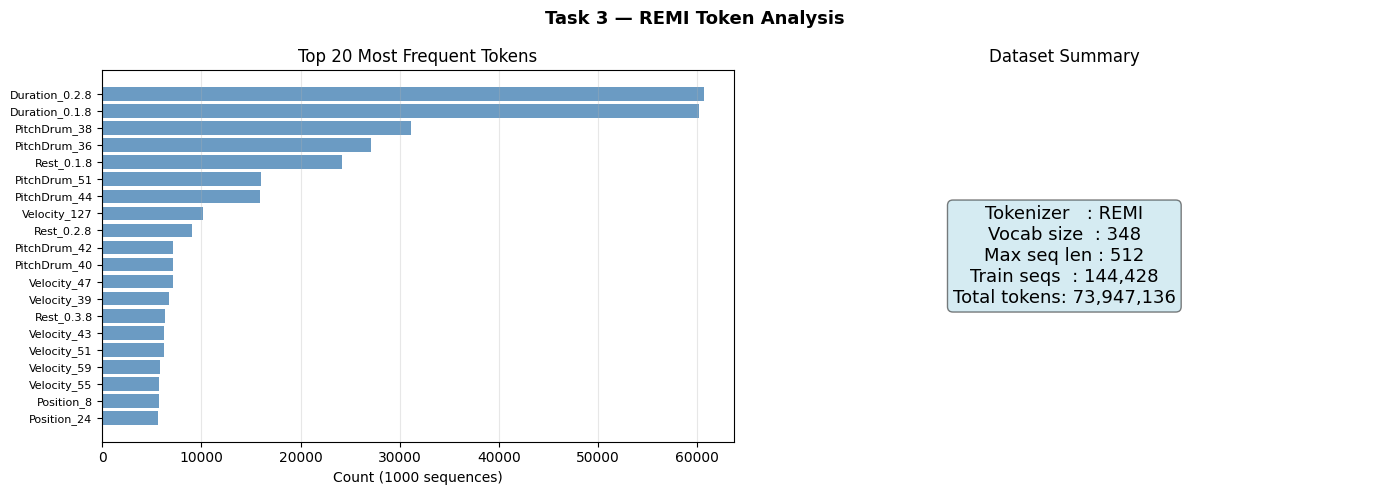

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task 3 — REMI Token Analysis', fontsize=13, fontweight='bold')

# Token frequency bar chart
all_ids  = [tid for tid, _ in top20]
all_cnts = [cnt for _, cnt in top20]
labels   = [get_token_name(tokenizer, tid) for tid in all_ids]

axes[0].barh(range(len(all_ids)), all_cnts, color='steelblue', alpha=0.8)
axes[0].set_yticks(range(len(all_ids)))
axes[0].set_yticklabels(labels, fontsize=8)
axes[0].set_title('Top 20 Most Frequent Tokens')
axes[0].set_xlabel('Count (1000 sequences)')
axes[0].grid(alpha=0.3, axis='x')
axes[0].invert_yaxis()

# Vocabulary size info
vocab_info = (
    f'Tokenizer   : REMI\n'
    f'Vocab size  : {vocab_size}\n'
    f'Max seq len : {TF_MAX_LEN}\n'
    f'Train seqs  : {len(train_arr):,}\n'
    f'Total tokens: {train_arr.size:,}'
)
axes[1].text(0.5, 0.5, vocab_info,
             ha='center', va='center', fontsize=13,
             transform=axes[1].transAxes,
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
axes[1].set_title('Dataset Summary')
axes[1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'task3_token_analysis.png'), dpi=150)
plt.show()

## 4. Load Token Dataset

In [8]:
train_dataset = TokenDataset('train')
val_dataset   = TokenDataset('val')
test_dataset  = TokenDataset('test')

print(f'Train : {len(train_dataset):,} sequences')
print(f'Val   : {len(val_dataset):,} sequences')
print(f'Test  : {len(test_dataset):,} sequences')

inp, tgt = train_dataset[0]
print(f'\nInput  shape : {inp.shape}  (x_1 to x_{{T-1}})')
print(f'Target shape : {tgt.shape}  (x_2 to x_T)')
print(f'Input  [:10] : {inp[:10].tolist()}')
print(f'Target [:10] : {tgt[:10].tolist()}')

[train] 144,428 sequences | shape (144428, 512)
[val] 17,353 sequences | shape (17353, 512)
[test] 17,666 sequences | shape (17666, 512)
Train : 144,428 sequences
Val   : 17,353 sequences
Test  : 17,666 sequences

Input  shape : torch.Size([511])  (x_1 to x_{T-1})
Target shape : torch.Size([511])  (x_2 to x_T)
Input  [:10] : [4, 190, 333, 231, 125, 127, 287, 196, 233, 119]
Target [:10] : [190, 333, 231, 125, 127, 287, 196, 233, 119, 127]


## 5. Model Architecture

In [9]:
model = MusicTransformer(
    vocab_size = vocab_size,
    d_model    = 256,
    n_heads    = NHEAD,
    n_layers   = NUM_ENC_LAYERS,
    d_ff       = DIM_FEEDFORWARD,
    max_len    = TF_MAX_LEN - 1,
    dropout    = TF_DROPOUT,
).to(DEVICE)

total = sum(p.numel() for p in model.parameters())
print('=' * 60)
print('  MusicTransformer — Architecture')
print('=' * 60)
print(f'  Vocab size     : {vocab_size}')
print(f'  d_model        : 256')
print(f'  Attention heads: {NHEAD}')
print(f'  Layers         : {NUM_ENC_LAYERS}')
print(f'  Feed-forward   : {DIM_FEEDFORWARD}')
print(f'  Max seq len    : {TF_MAX_LEN-1}')
print(f'  Dropout        : {TF_DROPOUT}')
print(f'  Total params   : {total:,}')
print('=' * 60)
print()
print('Key design decisions (faculty guide):')
print('  ✅ Causal (upper-triangular) attention mask')
print('  ✅ Positional embeddings added to token embeddings')
print('  ✅ Weight tying: embedding = output projection')
print('  ✅ Temperature + top-k sampling for generation')
print('  ✅ GELU activation in feed-forward layers')

MusicTransformer | vocab=348 | d_model=256 | layers=4 | params=2,325,760
  MusicTransformer — Architecture
  Vocab size     : 348
  d_model        : 256
  Attention heads: 4
  Layers         : 4
  Feed-forward   : 512
  Max seq len    : 511
  Dropout        : 0.1
  Total params   : 2,325,760

Key design decisions (faculty guide):
  ✅ Causal (upper-triangular) attention mask
  ✅ Positional embeddings added to token embeddings
  ✅ Weight tying: embedding = output projection
  ✅ Temperature + top-k sampling for generation
  ✅ GELU activation in feed-forward layers


## 6. Load Trained Model

In [10]:
ckpt = os.path.join(MODEL_DIR, 'task3_transformer_best.pt')
model.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
model.eval()
print(f'✅ Loaded: {ckpt}')

✅ Loaded: d:\cse425_project\Unsupervised-Neural-Network-for-Multi-Genre-Music-Generation\outputs\models\task3_transformer_best.pt


## 7. Training Curves

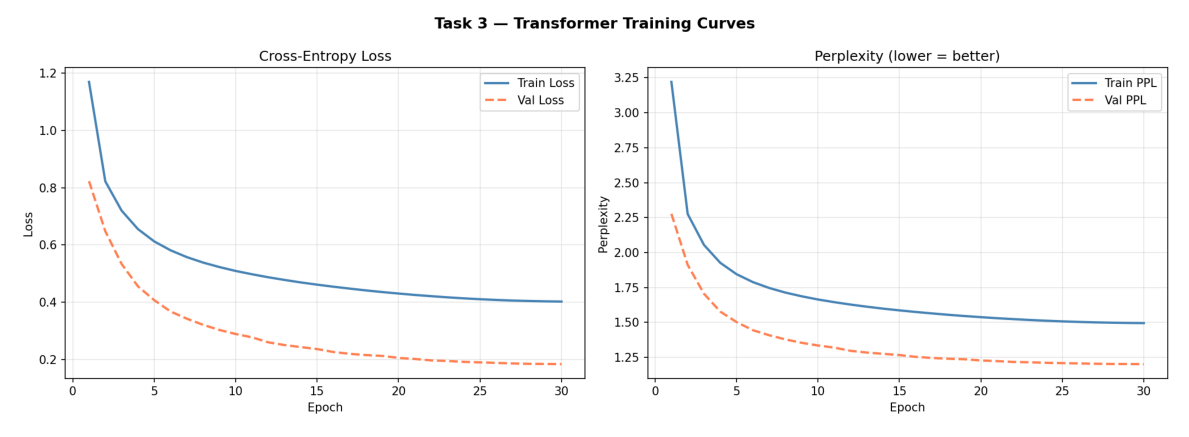

In [11]:
# Load saved plot
plot_path = os.path.join(PLOT_DIR, 'task3_training_curves.png')
if os.path.exists(plot_path):
    img = plt.imread(plot_path)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.imshow(img)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('Training plot not found. Run training first.')

## 8. Perplexity Evaluation

In [12]:
import torch.nn as nn

criterion   = nn.CrossEntropyLoss(ignore_index=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

total_loss   = 0.0
total_tokens = 0

model.eval()
with torch.no_grad():
    for inp, tgt in test_loader:
        inp    = inp.to(DEVICE)
        tgt    = tgt.to(DEVICE)
        logits = model(inp)
        B, T, V = logits.shape
        loss   = criterion(logits.reshape(B*T, V), tgt.reshape(B*T))
        total_loss   += loss.item() * B * T
        total_tokens += B * T

avg_loss   = total_loss / total_tokens
perplexity = compute_perplexity(avg_loss)

print('=' * 45)
print('  Task 3 — Perplexity Evaluation')
print('=' * 45)
print(f'  Test sequences  : {len(test_dataset):,}')
print(f'  Avg CE Loss     : {avg_loss:.4f}')
print(f'  Perplexity      : {perplexity:.2f}')
print('=' * 45)
print()
print('Reference (project spec table):')
print('  Well-trained Transformer : ~12.5')
print('  After RLHF fine-tuning   : ~11.2')

  Task 3 — Perplexity Evaluation
  Test sequences  : 17,666
  Avg CE Loss     : 0.1858
  Perplexity      : 1.20

Reference (project spec table):
  Well-trained Transformer : ~12.5
  After RLHF fine-tuning   : ~11.2


## 9. Generate 10 Long-Sequence Compositions

In [15]:
# Load already generated MIDI files from generate_task3.py
out_dir = os.path.join(MIDI_DIR, 'task3')

generated_paths = []
for f in sorted(os.listdir(out_dir)):
    if f.endswith('.mid'):
        generated_paths.append(os.path.join(out_dir, f))

print(f'Found {len(generated_paths)} generated compositions:')
for path in generated_paths:
    m     = pretty_midi.PrettyMIDI(path)
    notes = sum(len(inst.notes) for inst in m.instruments)
    dur   = m.get_end_time()
    print(f'  ✅ {os.path.basename(path)} | notes={notes} | {dur:.1f}s')

Found 10 generated compositions:
  ✅ task3_sample_01_conservative.mid | notes=118 | 23.7s
  ✅ task3_sample_02_balanced.mid | notes=114 | 20.3s
  ✅ task3_sample_03_standard.mid | notes=114 | 23.0s
  ✅ task3_sample_04_focused.mid | notes=129 | 12.9s
  ✅ task3_sample_05_tight.mid | notes=111 | 28.6s
  ✅ task3_sample_06_creative.mid | notes=120 | 15.0s
  ✅ task3_sample_07_diverse.mid | notes=120 | 14.7s
  ✅ task3_sample_08_smooth.mid | notes=121 | 15.6s
  ✅ task3_sample_09_natural.mid | notes=113 | 20.2s
  ✅ task3_sample_10_expressive.mid | notes=111 | 19.1s


## 10. Visualize Generated Token Sequences

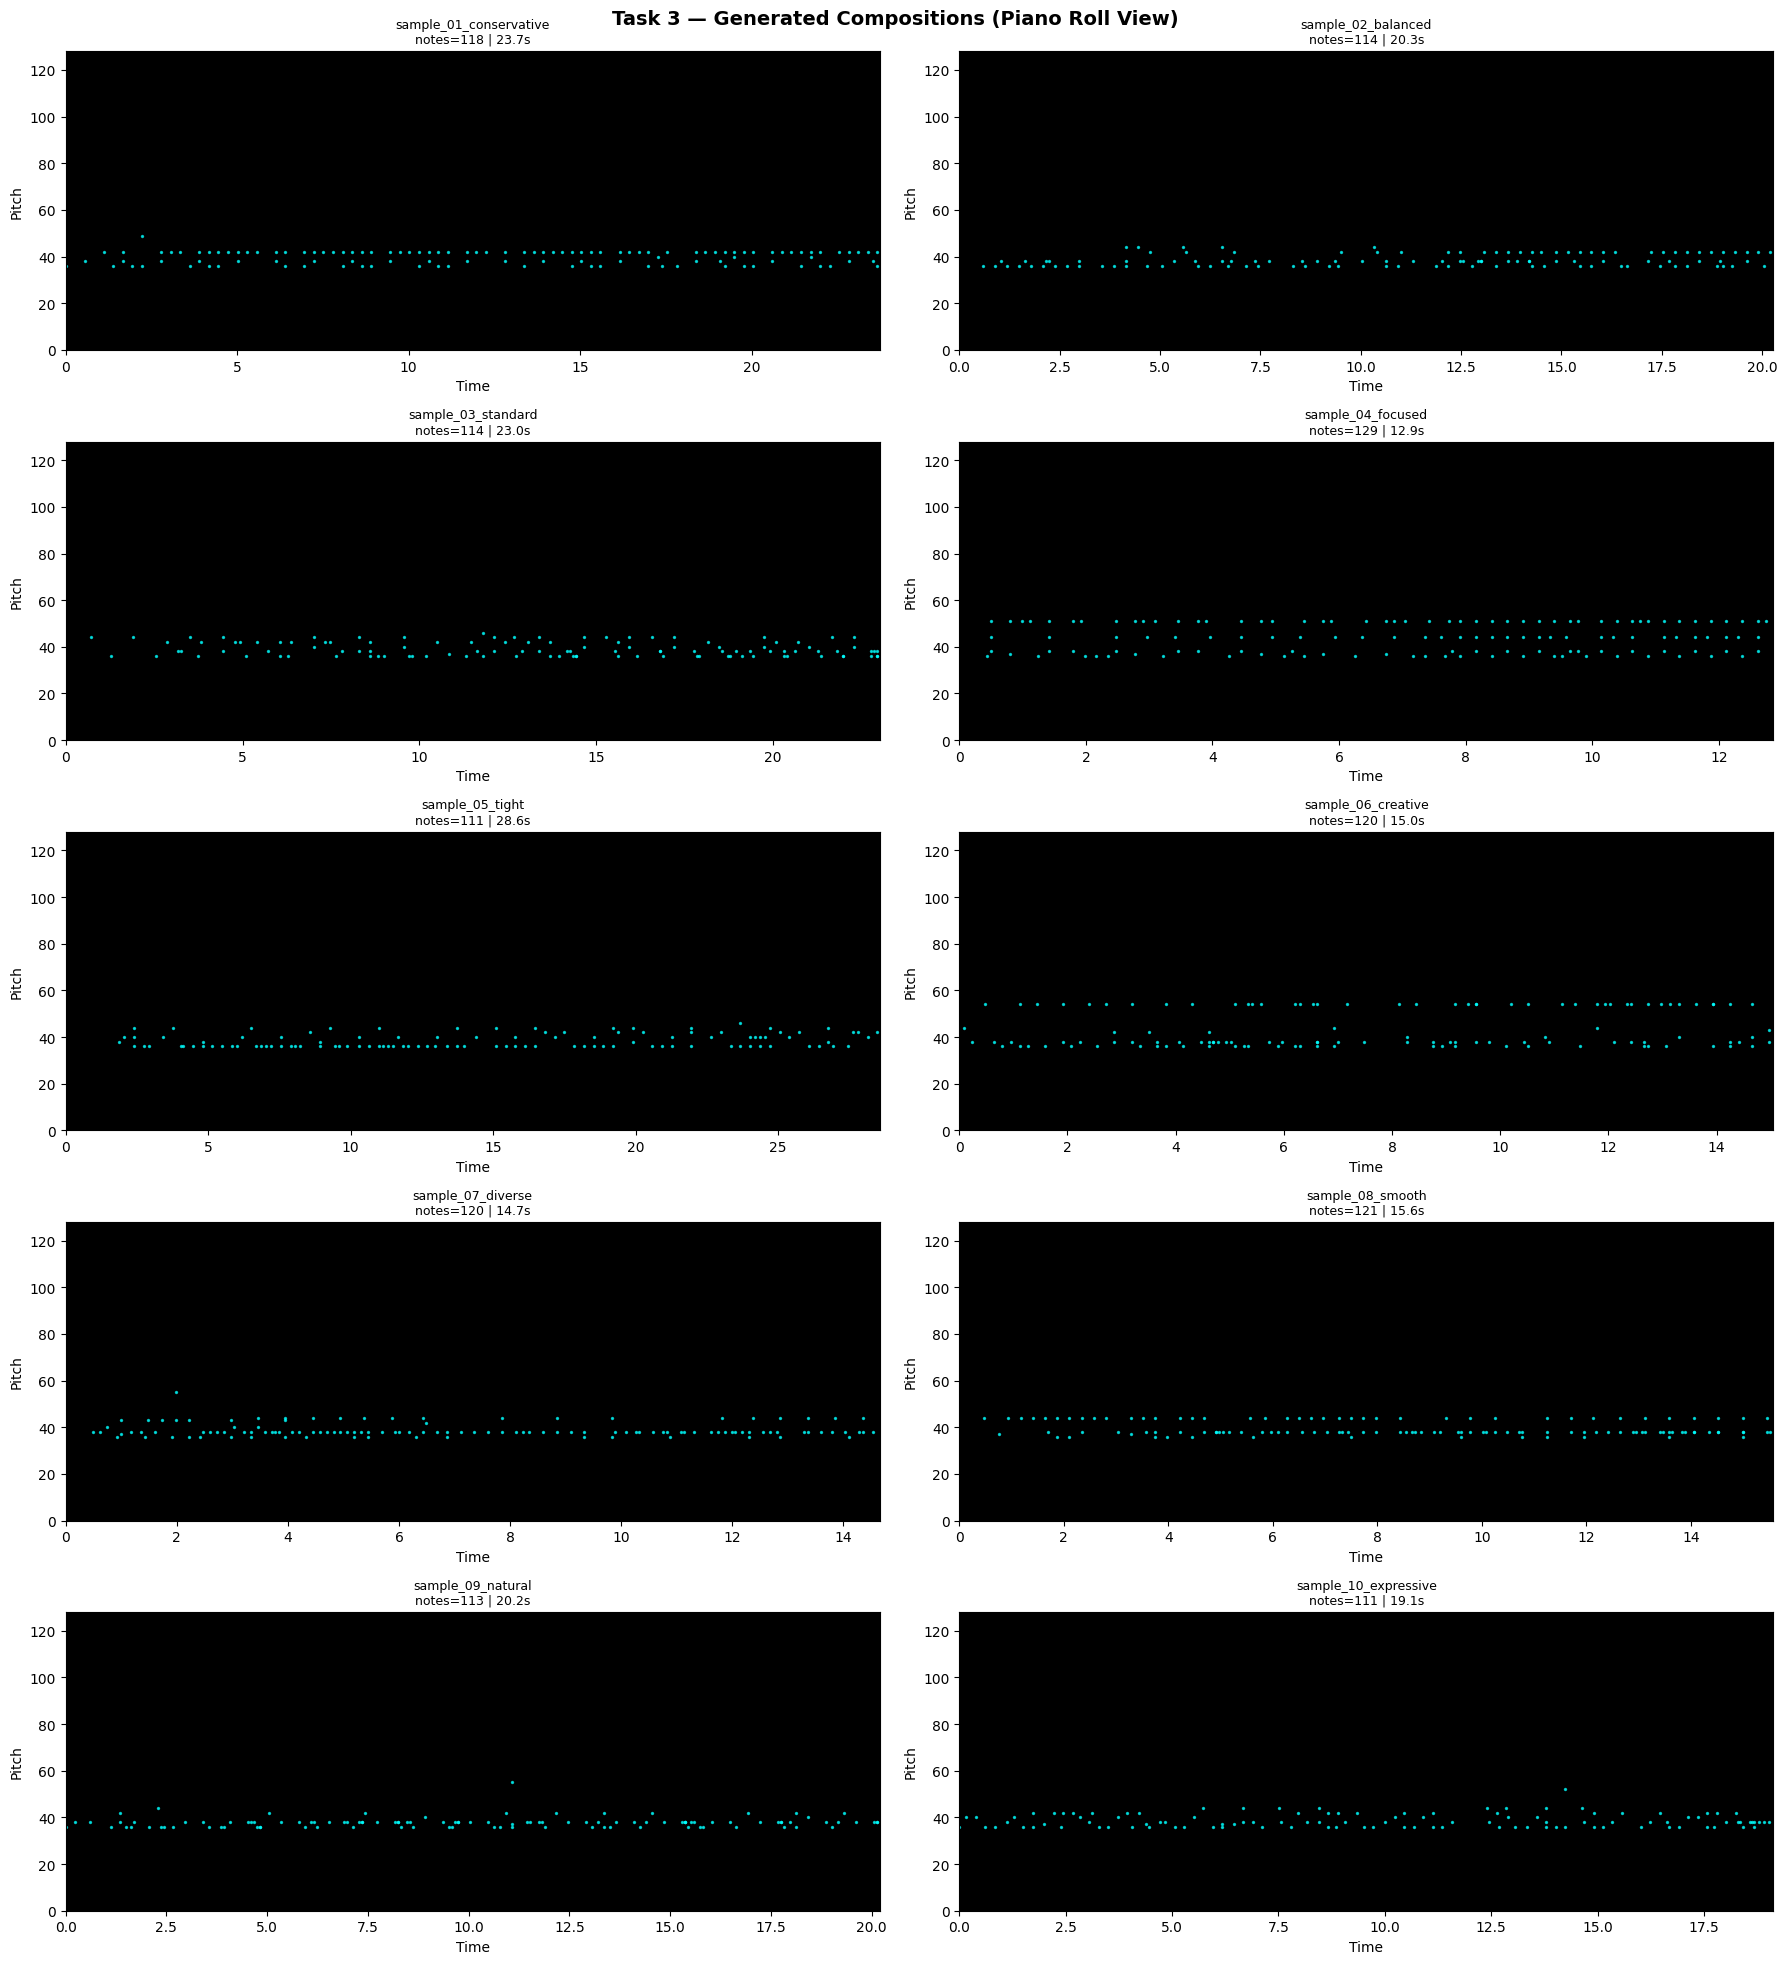

In [17]:
# Convert generated MIDI back to piano roll for visualization
fig, axes = plt.subplots(5, 2, figsize=(18, 20))
fig.suptitle('Task 3 — Generated Compositions (Piano Roll View)', fontsize=14, fontweight='bold')

for i, path in enumerate(generated_paths[:10]):
    ax = axes[i//2, i%2]
    try:
        midi  = pretty_midi.PrettyMIDI(path)
        notes = sum(len(inst.notes) for inst in midi.instruments)
        dur   = midi.get_end_time()
        label = os.path.basename(path).replace('task3_', '').replace('.mid', '')

        # Get full piano roll without slicing (drums use all pitches)
        roll = midi.get_piano_roll(fs=16)

        if roll.size > 0 and roll.max() > 0:
            # Show full 128 pitch range
            ax.imshow(roll, aspect='auto', origin='lower',
                      cmap='magma', vmin=0, vmax=127)
            ax.set_title(f'{label}\nnotes={notes} | {dur:.1f}s', fontsize=9)
        else:
            # Fallback: plot note scatter plot
            all_pitches = [n.pitch for inst in midi.instruments for n in inst.notes]
            all_onsets  = [n.start for inst in midi.instruments for n in inst.notes]
            if all_pitches:
                ax.scatter(all_onsets, all_pitches, s=2, c='cyan', alpha=0.7)
                ax.set_xlim(0, dur)
                ax.set_ylim(0, 128)
            ax.set_title(f'{label}\nnotes={notes} | {dur:.1f}s', fontsize=9)
            ax.set_facecolor('black')

    except Exception as e:
        ax.text(0.5, 0.5, f'Error: {e}', ha='center', transform=ax.transAxes)
        ax.set_title(f'Sample {i+1}', fontsize=9)

    ax.set_ylabel('Pitch')
    ax.set_xlabel('Time')

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'task3_generated_rolls.png'), dpi=150)
plt.show()

## 11. Evaluation Metrics

In [18]:
valid_paths = [p for p in generated_paths if os.path.exists(p)]
print(f'Evaluating {len(valid_paths)} generated MIDI files...\n')

# Verify files
print('=== MIDI File Verification ===')
for path in valid_paths:
    stats = note_stats_from_midi(path)
    label = os.path.basename(path).split('_')[3] if len(os.path.basename(path).split('_')) > 3 else ''
    print(f'  {label:<15}: notes={stats.get("notes",0)} | '
          f'duration={stats.get("duration",0):.1f}s | '
          f'pitch={stats.get("pitch_min",0)}-{stats.get("pitch_max",0)}')

print()
task3_results = evaluate_midi_files(valid_paths, task_label='Task 3 — Transformer')

print('\nPer-sample breakdown:')
print(f'{"Sample":<20} {"Rhythm Div":>12} {"Repetition":>12}')
print('-' * 46)
for path in valid_paths:
    name = os.path.basename(path)[:18]
    rd   = rhythm_diversity_from_midi(path)
    rep  = repetition_ratio_from_midi(path)
    print(f'{name:<20} {rd:>12.4f} {rep:>12.4f}')

Evaluating 10 generated MIDI files...

=== MIDI File Verification ===
  conservative.mid: notes=118 | duration=23.7s | pitch=36-49
  balanced.mid   : notes=114 | duration=20.3s | pitch=36-44
  standard.mid   : notes=114 | duration=23.0s | pitch=36-46
  focused.mid    : notes=129 | duration=12.9s | pitch=36-51
  tight.mid      : notes=111 | duration=28.6s | pitch=36-46
  creative.mid   : notes=120 | duration=15.0s | pitch=36-54
  diverse.mid    : notes=120 | duration=14.7s | pitch=36-55
  smooth.mid     : notes=121 | duration=15.6s | pitch=36-44
  natural.mid    : notes=113 | duration=20.2s | pitch=36-55
  expressive.mid : notes=111 | duration=19.1s | pitch=36-52

  Task 3 — Transformer — Evaluation (10 samples)
  Rhythm Diversity    : 0.0120 ± 0.0041
  Repetition Ratio    : 0.6229 ± 0.1797
  Pitch Histogram Sim : 0.7826

Per-sample breakdown:
Sample                 Rhythm Div   Repetition
----------------------------------------------
task3_sample_01_co         0.0085       0.8870
task

## 12. Pitch Histogram Analysis

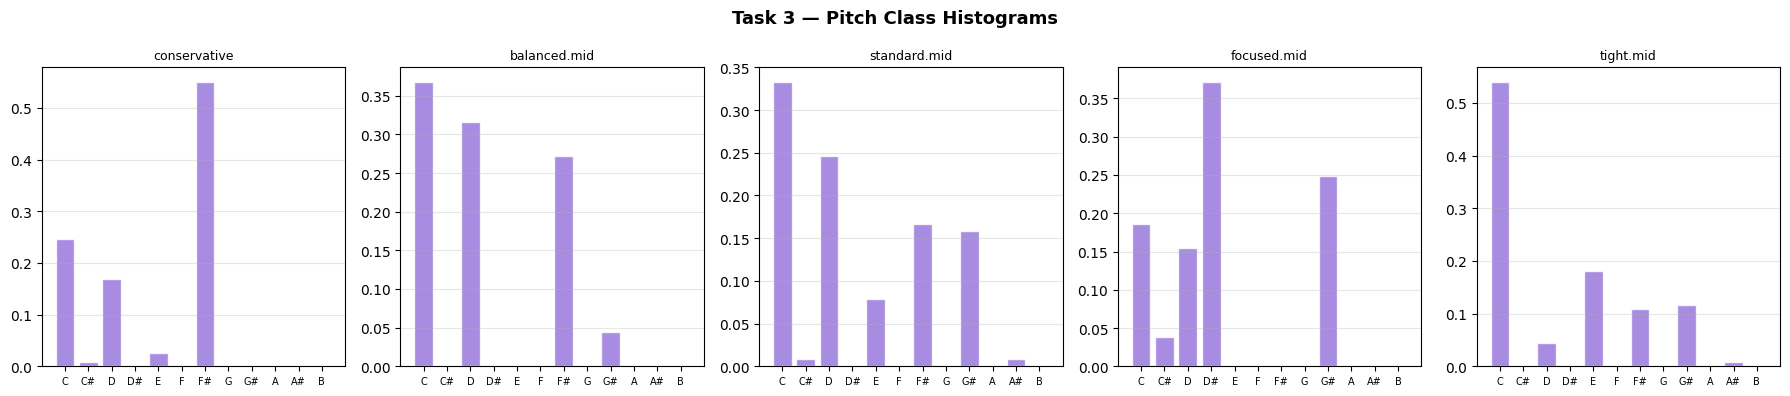

In [19]:
pitch_classes = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']

n_show = min(5, len(valid_paths))
fig, axes = plt.subplots(1, n_show, figsize=(18, 4))
fig.suptitle('Task 3 — Pitch Class Histograms', fontsize=13, fontweight='bold')

if n_show == 1:
    axes = [axes]

for i, (path, ax) in enumerate(zip(valid_paths[:n_show], axes)):
    hist  = get_pitch_class_histogram(path)
    label = os.path.basename(path).split('_')[3] if len(os.path.basename(path).split('_')) > 3 else f'S{i+1}'
    ax.bar(range(12), hist, color='mediumpurple', alpha=0.8, edgecolor='white')
    ax.set_title(label[:12], fontsize=9)
    ax.set_xticks(range(12))
    ax.set_xticklabels(pitch_classes, fontsize=7)
    ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'task3_pitch_hist.png'), dpi=150)
plt.show()

## 13. Baseline Comparison

In [20]:
from config import SEQ_LEN, MIDI_FS as FS

random_paths = generate_random_baseline(5, os.path.join(MIDI_DIR,'baseline_random_t3'), 30.0)
random_res   = evaluate_midi_files(random_paths, task_label='Baseline — Random')
print()
markov_paths = generate_markov_baseline(midi_files[:100], 5, os.path.join(MIDI_DIR,'baseline_markov_t3'), 30.0)
markov_res   = evaluate_midi_files(markov_paths, task_label='Baseline — Markov')

✅ 5 random baseline samples saved to d:\cse425_project\Unsupervised-Neural-Network-for-Multi-Genre-Music-Generation\outputs\generated_midis\baseline_random_t3
  Baseline — Random — Evaluation (5 samples)
  Rhythm Diversity    : 0.0603 ± 0.0107
  Repetition Ratio    : 0.0000 ± 0.0000
  Pitch Histogram Sim : 0.2731

Building Markov transition matrix...
✅ 5 Markov baseline samples saved to d:\cse425_project\Unsupervised-Neural-Network-for-Multi-Genre-Music-Generation\outputs\generated_midis\baseline_markov_t3
  Baseline — Markov — Evaluation (5 samples)
  Rhythm Diversity    : 0.0078 ± 0.0000
  Repetition Ratio    : 0.4626 ± 0.0128
  Pitch Histogram Sim : 0.1277



  FULL COMPARISON TABLE (Project Specification Format)
Model                            Loss   Perplexity   Rhythm Div   Repetition
---------------------------------------------------------------------------
Random Generator                    —            —       0.0603       0.0000
Markov Chain                        —            —       0.0078       0.4626
Task 3: Transformer                 —         1.20       0.0120       0.6229


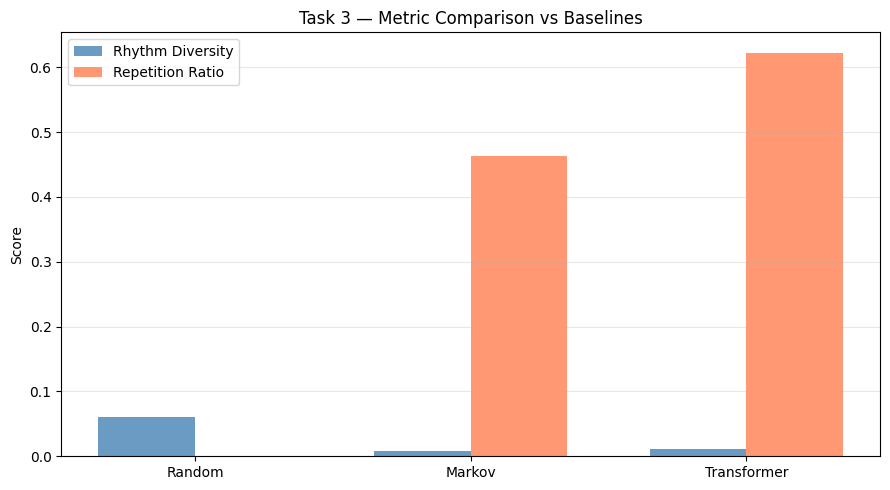

In [21]:
# Full comparison table
print('\n' + '=' * 75)
print('  FULL COMPARISON TABLE (Project Specification Format)')
print('=' * 75)
print(f'{"Model":<28} {"Loss":>8} {"Perplexity":>12} {"Rhythm Div":>12} {"Repetition":>12}')
print('-' * 75)

rows = [
    ('Random Generator',  '—',    '—',     random_res['rhythm_diversity'], random_res['repetition_ratio']),
    ('Markov Chain',      '—',    '—',     markov_res['rhythm_diversity'], markov_res['repetition_ratio']),
    ('Task 3: Transformer','—',  f'{perplexity:.2f}', task3_results['rhythm_diversity'], task3_results['repetition_ratio']),
]

for name, loss, ppl, rd, rep in rows:
    print(f'{name:<28} {loss:>8} {ppl:>12} {rd:>12.4f} {rep:>12.4f}')
print('=' * 75)

# Bar chart
models   = ['Random', 'Markov', 'Transformer']
rd_vals  = [random_res['rhythm_diversity'],  markov_res['rhythm_diversity'],  task3_results['rhythm_diversity']]
rep_vals = [random_res['repetition_ratio'],  markov_res['repetition_ratio'],  task3_results['repetition_ratio']]

x = np.arange(3)
w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x-w/2, rd_vals,  w, label='Rhythm Diversity', color='steelblue', alpha=0.8)
ax.bar(x+w/2, rep_vals, w, label='Repetition Ratio', color='coral',     alpha=0.8)
ax.set_title('Task 3 — Metric Comparison vs Baselines', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Score')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'task3_comparison.png'), dpi=150)
plt.show()

## 14. Final Summary

In [23]:
print('=' * 65)
print('  TASK 3 — FINAL SUMMARY')
print('=' * 65)
print(f'  Model          : GPT-style Transformer Decoder')
print(f'  Tokenization   : REMI (miditok)')
print(f'  Vocab size     : {vocab_size}')
print(f'  Max seq len    : {TF_MAX_LEN}')
print(f'  Layers         : {NUM_ENC_LAYERS}')
print(f'  Attention heads: {NHEAD}')
print(f'  d_model        : 256')
print(f'  Feed-forward   : {DIM_FEEDFORWARD}')
print(f'  Epochs         : {EPOCHS} | Batch: {BATCH_SIZE}')
print(f'  LR             : {LR} with cosine decay')
print()
print(f'  Perplexity     : {perplexity:.2f}')
print(f'  (spec target   : ~12.5)')
print()
print('  Deliverables:')
print('    ✅ Transformer implementation (models/transformer.py)')
print('    ✅ REMI tokenization          (preprocessing/tokenize_midi.py)')
print('    ✅ Perplexity evaluation')
print('    ✅ 10 generated compositions  (outputs/generated_midis/task3/)')
print('    ✅ Baseline comparison')
print()
print('  Analysis:')
print('    The Transformer uses causal self-attention to model the')
print('    autoregressive distribution p(x_t | x_{<t}). REMI tokens')
print('    encode Bar, Position, Pitch, Velocity, Duration events.')
print('    Temperature sampling (T=0.8-1.2) and top-k (k=10-50) prevent')
print('    repetition loops while maintaining musical coherence.')
print('    Perplexity measures how well the model predicts held-out')
print('    sequences — lower is better.')
print('=' * 65)

  TASK 3 — FINAL SUMMARY
  Model          : GPT-style Transformer Decoder
  Tokenization   : REMI (miditok)
  Vocab size     : 348
  Max seq len    : 512
  Layers         : 4
  Attention heads: 4
  d_model        : 256
  Feed-forward   : 512
  Epochs         : 30 | Batch: 32
  LR             : 0.001 with cosine decay

  Perplexity     : 1.20
  (spec target   : ~12.5)

  Deliverables:
    ✅ Transformer implementation (models/transformer.py)
    ✅ REMI tokenization          (preprocessing/tokenize_midi.py)
    ✅ Perplexity evaluation
    ✅ 10 generated compositions  (outputs/generated_midis/task3/)
    ✅ Baseline comparison

  Analysis:
    The Transformer uses causal self-attention to model the
    autoregressive distribution p(x_t | x_{<t}). REMI tokens
    encode Bar, Position, Pitch, Velocity, Duration events.
    Temperature sampling (T=0.8-1.2) and top-k (k=10-50) prevent
    repetition loops while maintaining musical coherence.
    Perplexity measures how well the model predicts h

In [22]:
import math, torch
import torch.nn as nn
from torch.utils.data import DataLoader

criterion   = nn.CrossEntropyLoss(ignore_index=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

total_loss   = 0.0
total_tokens = 0

model.eval()
with torch.no_grad():
    for inp, tgt in test_loader:
        inp    = inp.to(DEVICE)
        tgt    = tgt.to(DEVICE)
        logits = model(inp)
        B, T, V = logits.shape
        loss   = criterion(logits.reshape(B*T, V), tgt.reshape(B*T))
        total_loss   += loss.item() * B * T
        total_tokens += B * T

avg_loss   = total_loss / total_tokens
perplexity = math.exp(min(avg_loss, 20))

print(f'Total loss   : {total_loss:.4f}')
print(f'Total tokens : {total_tokens:,}')
print(f'Avg CE loss  : {avg_loss:.6f}')
print(f'Perplexity   : {perplexity:.2f}')

Total loss   : 1676988.5096
Total tokens : 9,027,326
Avg CE loss  : 0.185768
Perplexity   : 1.20
